In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values to stay in range
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [5]:
model = keras.Sequential([

    # Encoder
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),

    # Decoder
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(784, activation='sigmoid'),
    keras.layers.Reshape((28,28))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [7]:
history = model.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.2078 - val_loss: 0.1537
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.1446 - val_loss: 0.1358
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.1332 - val_loss: 0.1285
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.1271 - val_loss: 0.1241
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.1235 - val_loss: 0.1210
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1210 - val_loss: 0.1191
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.1189 - val_loss: 0.1179
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.1171 - val_loss: 0.1168
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.1157 - val_loss: 0.1153
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.1144 - val_loss: 0.1140


In [8]:
decoded_images = model.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


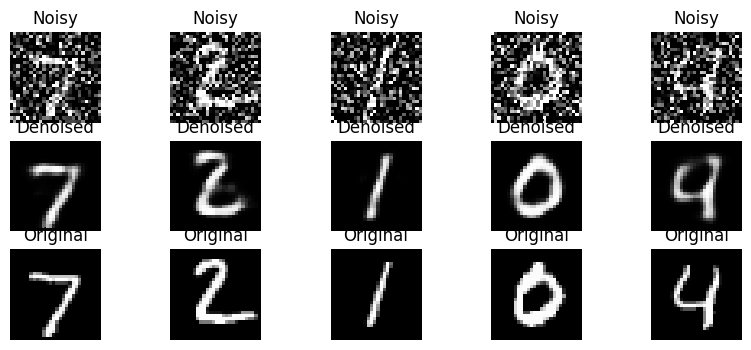

In [9]:
n = 5
plt.figure(figsize=(10,4))

for i in range(n):
    # Noisy image
    plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i], cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised image
    plt.subplot(3, n, i+n+1)
    plt.imshow(decoded_images[i], cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # Original image
    plt.subplot(3, n, i+2*n+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.show()

# 📘 Cell-wise Explanation of Autoencoder for Image Denoising

### 🔹 Cell 1: Import Libraries

Imports TensorFlow/Keras for model building, NumPy for numerical operations, and Matplotlib for visualization.

---

### 🔹 Cell 2: Load Dataset

Loads MNIST dataset. Labels are ignored since this is an unsupervised learning task.

---

### 🔹 Cell 3: Normalize Data

Scales pixel values from 0–255 to 0–1 for better model performance.

---

### 🔹 Cell 4: Add Noise

Random Gaussian noise is added to images to create noisy inputs. Values are clipped to maintain valid pixel range.

---

### 🔹 Cell 5: Build Autoencoder

Defines encoder (compress input) and decoder (reconstruct image). The model learns a compressed representation of the input.

---

### 🔹 Cell 6: Compile Model

Uses Adam optimizer and binary crossentropy loss for reconstruction.

---

### 🔹 Cell 7: Train Model

Model is trained using noisy images as input and clean images as target.

---

### 🔹 Cell 8: Denoise Images

Model predicts clean images from noisy test inputs.

---

### 🔹 Cell 9: Display Results

Shows comparison between noisy, denoised, and original images.

---

# ✅ Conclusion

The autoencoder successfully learned to remove noise and reconstruct clean images, demonstrating its effectiveness in image denoising tasks.


# 📊 Dataset Description: MNIST Dataset

### 📌 Description

The MNIST dataset consists of grayscale images of handwritten digits (0–9). It is widely used for image processing and deep learning tasks.

### 📊 Features

* Each image is **28 × 28 pixels (grayscale)**
* Pixel values range from **0 to 255**

### 🎯 Target Variable

* In this experiment, the target is the **original clean image itself**
* Type: **Reconstruction problem (unsupervised learning)**

### 📦 Dataset Size

* Training samples: **60,000 images**
* Testing samples: **10,000 images**

### ⭐ Key Characteristics

* Simple dataset suitable for reconstruction tasks
* Used to train models to learn compressed representations
* Noise can be artificially added for denoising tasks
